<a href="https://colab.research.google.com/github/umair594/Decode-labs-data-analytics-internship/blob/main/Exploratory_Data_Analysis_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 2: Exploratory Data Analysis - EDA**

Dataset: **Superstore Sales Dataset**

# **1. Import Libraries**

In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Professional visualization style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 11

# **2. Load Dataset**

In [3]:
# 2. Load Dataset
df = pd.read_csv("train.csv")

# **3. Introduction**

In [4]:
# 3. Introduction
print("PROJECT 2: EXPLORATORY DATA ANALYSIS")
print("Dataset: Superstore Sales Dataset")
print("Objective: Analyze sales patterns, trends, distributions, and outliers.")
print("-" * 60)

PROJECT 2: EXPLORATORY DATA ANALYSIS
Dataset: Superstore Sales Dataset
Objective: Analyze sales patterns, trends, distributions, and outliers.
------------------------------------------------------------


# **4. Basic Dataset Information**

In [6]:
# 4. Basic Dataset Information
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Dataset Shape: (9800, 18)

Columns:
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [8]:
print("\nFirst 5 Rows:")
display(df.head())


First 5 Rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [9]:
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null  

# **5. Data Cleaning**

In [10]:
# 5. Data Cleaning
print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


Missing Values:
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Duplicate Rows: 0


In [11]:
# Convert dates
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

# Create useful date columns
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Month Name"] = df["Order Date"].dt.month_name()
df["Shipping Days"] = (df["Ship Date"] - df["Order Date"]).dt.days

# **6. Descriptive Statistics**

In [12]:
print("\nSales Descriptive Statistics:")
display(df["Sales"].describe())


Sales Descriptive Statistics:


,Sales
count,9800.000000
mean,230.769059
std,626.651875
min,0.444000
25%,17.248000
50%,54.490000
75%,210.605000
max,22638.480000


In [13]:
print("\nMean Sales:", round(df["Sales"].mean(), 2))
print("Median Sales:", round(df["Sales"].median(), 2))
print("Total Sales:", round(df["Sales"].sum(), 2))
print("Minimum Sales:", round(df["Sales"].min(), 2))
print("Maximum Sales:", round(df["Sales"].max(), 2))


Mean Sales: 230.77
Median Sales: 54.49
Total Sales: 2261536.78
Minimum Sales: 0.44
Maximum Sales: 22638.48


# **7. Five Number Summary**

In [15]:
Q1 = df["Sales"].quantile(0.25)
Q2 = df["Sales"].median()
Q3 = df["Sales"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["Sales"] < lower_bound) | (df["Sales"] > upper_bound)]

print("\nFive Number Summary:")
print("Q1:", round(Q1, 2))
print("Median:", round(Q2, 2))
print("Q3:", round(Q3, 2))
print("IQR:", round(IQR, 2))
print("Lower Bound:", round(lower_bound, 2))
print("Upper Bound:", round(upper_bound, 2))
print("Number of Outliers:", outliers.shape[0])



Five Number Summary:
Q1: 17.25
Median: 54.49
Q3: 210.6
IQR: 193.36
Lower Bound: -272.79
Upper Bound: 500.64
Number of Outliers: 1145


# **8. Sales Distribution**

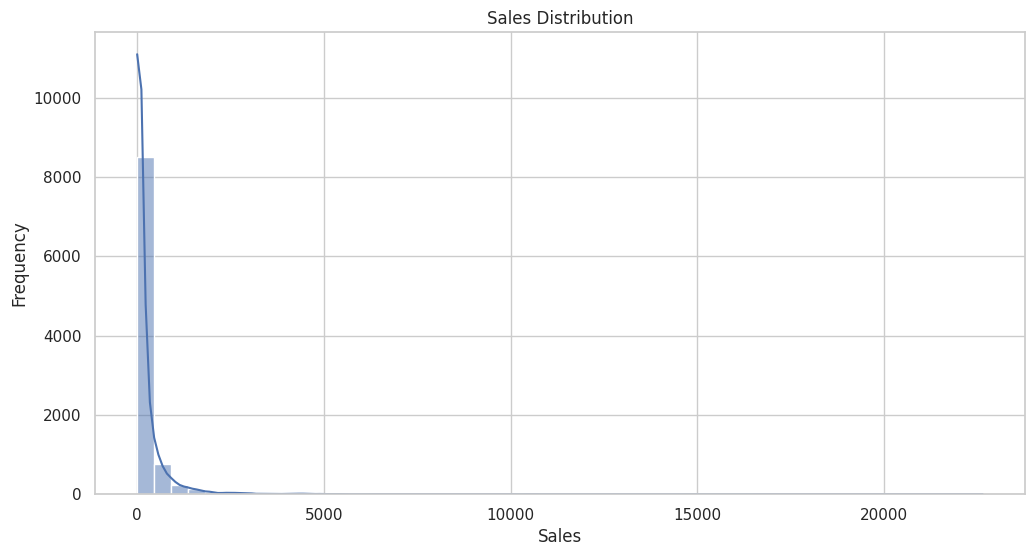

In [16]:
plt.figure()
sns.histplot(df["Sales"], bins=50, kde=True)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# **9. Boxplot for Outlier Detection**

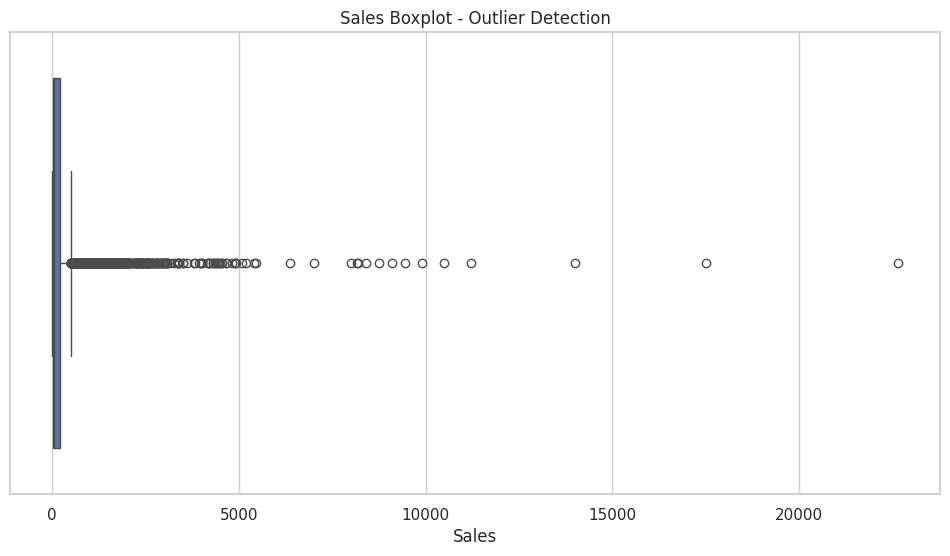

In [17]:
plt.figure()
sns.boxplot(x=df["Sales"])
plt.title("Sales Boxplot - Outlier Detection")
plt.xlabel("Sales")
plt.show()

# **10. Total Sales by Category**

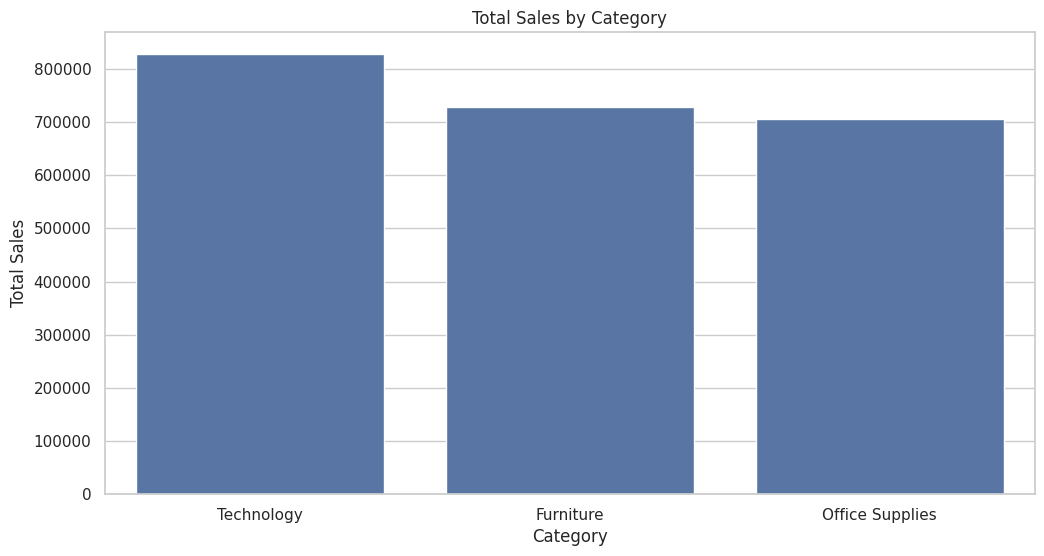

,Category,Sales
0,Technology,827455.8730
1,Furniture,728658.5757
2,Office Supplies,705422.3340


In [19]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=category_sales.index, y=category_sales.values)
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

display(category_sales.reset_index())

# **11. Total Sales by Region**

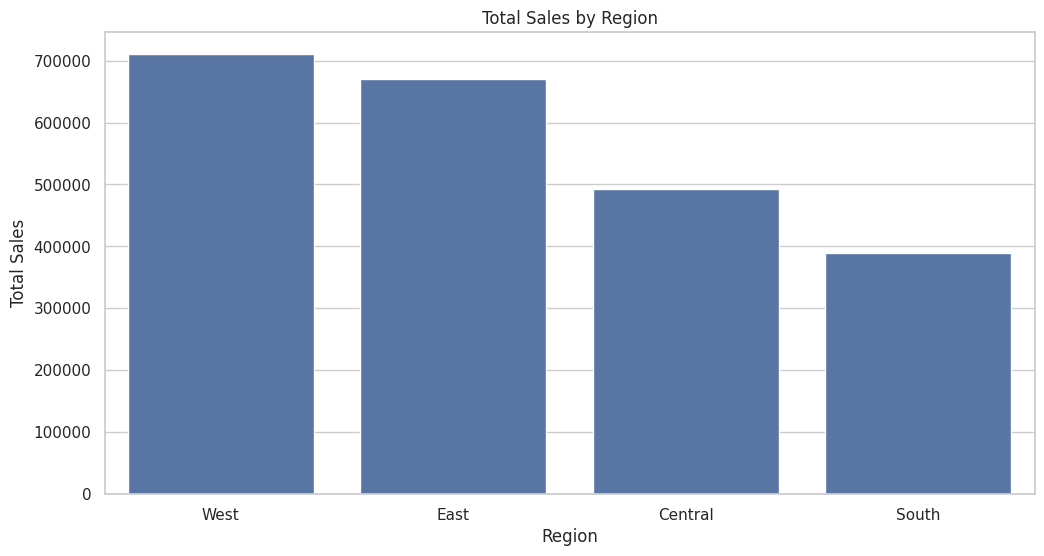

,Region,Sales
0,West,710219.6845
1,East,669518.7260
2,Central,492646.9132
3,South,389151.4590


In [20]:
region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=region_sales.index, y=region_sales.values)
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

display(region_sales.reset_index())

# **12. Sales by Segment**

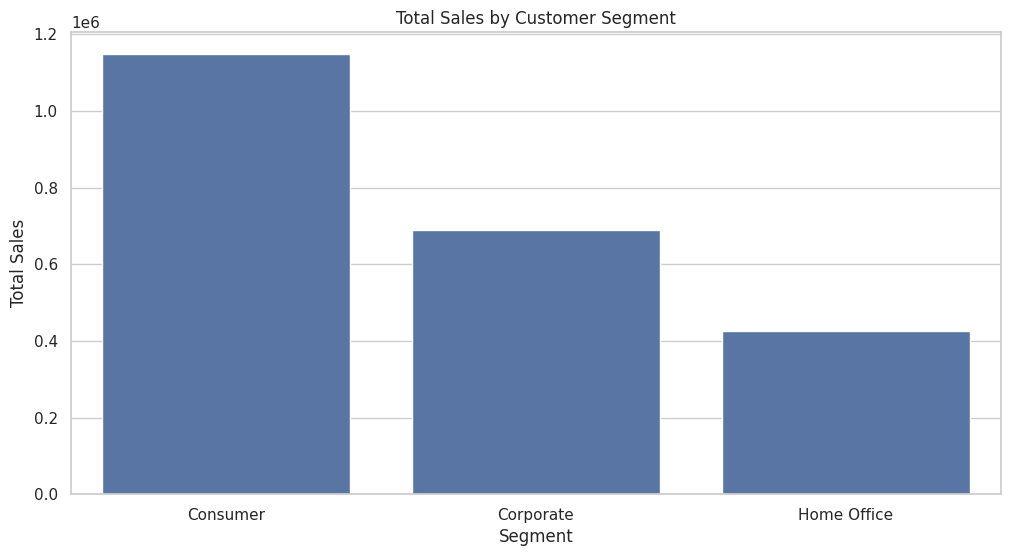

,Segment,Sales
0,Consumer,1.148061e+06
1,Corporate,6.884941e+05
2,Home Office,4.249822e+05


In [21]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

plt.figure()
sns.barplot(x=segment_sales.index, y=segment_sales.values)
plt.title("Total Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

display(segment_sales.reset_index())


# **13. Top 10 Sub-Categories by Sales**

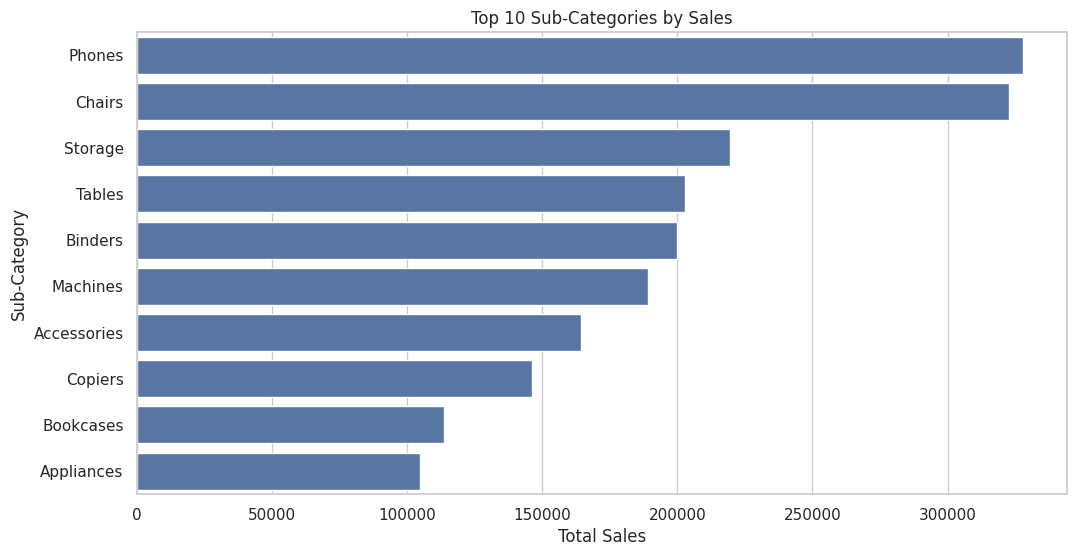

,Sub-Category,Sales
0,Phones,327782.4480
1,Chairs,322822.7310
2,Storage,219343.3920
3,Tables,202810.6280
4,Binders,200028.7850
5,Machines,189238.6310
6,Accessories,164186.7000
7,Copiers,146248.0940
8,Bookcases,113813.1987
9,Appliances,104618.4030


In [22]:
# 13. Top 10 Sub-Categories by Sales
subcategory_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=subcategory_sales.values, y=subcategory_sales.index)
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.show()

display(subcategory_sales.reset_index())

# **14. Monthly Sales Trend**

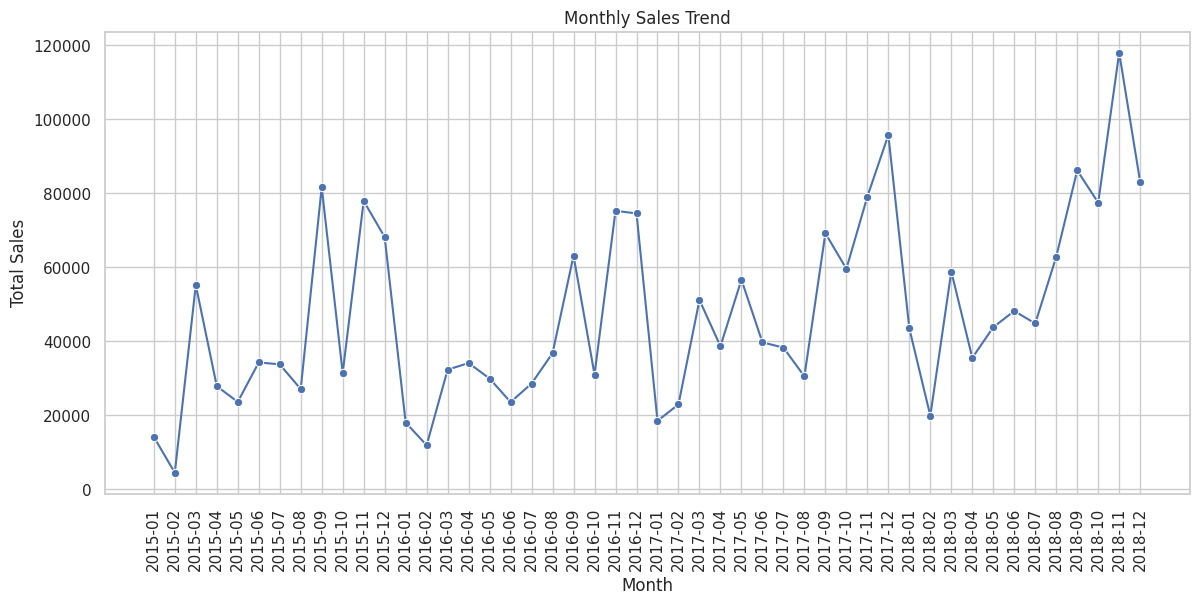

In [23]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

# **15. Yearly Sales Trend**

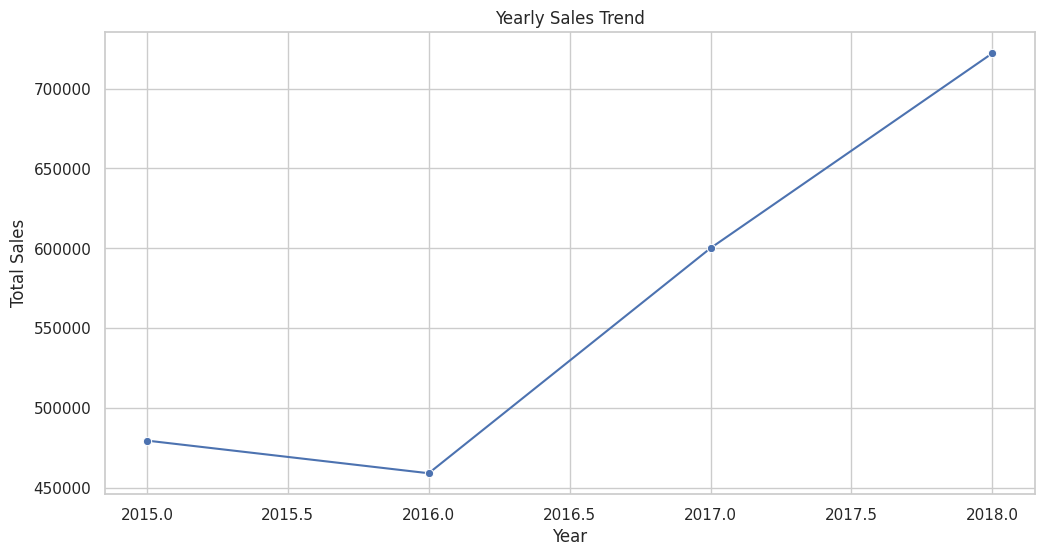

,Order Year,Sales
0,2015,479856.2081
1,2016,459436.0054
2,2017,600192.5500
3,2018,722052.0192


In [24]:
yearly_sales = df.groupby("Order Year")["Sales"].sum()

plt.figure()
sns.lineplot(x=yearly_sales.index, y=yearly_sales.values, marker="o")
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

display(yearly_sales.reset_index())

# **16. Top 10 States by Sales**

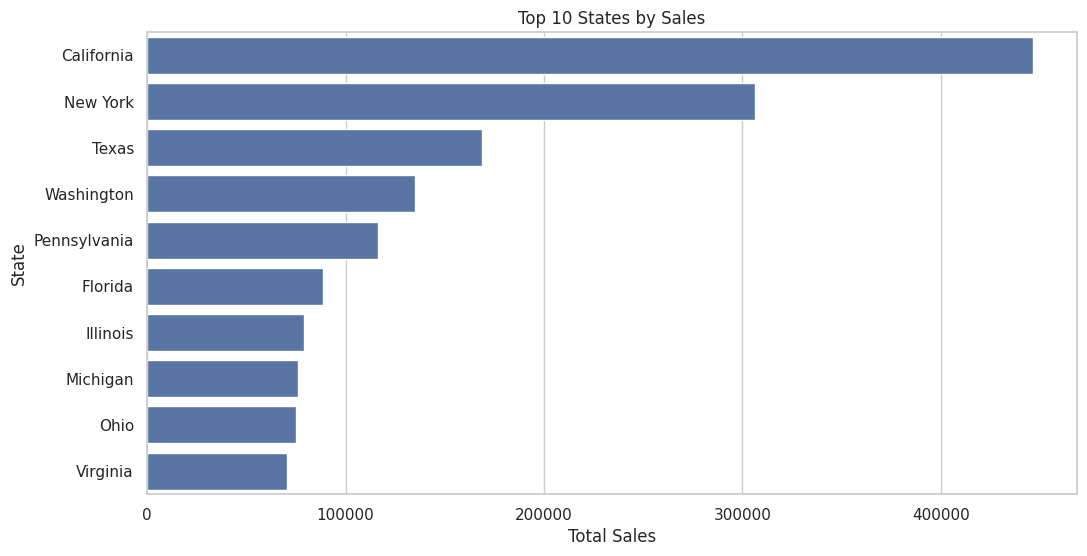

,State,Sales
0,California,446306.4635
1,New York,306361.1470
2,Texas,168572.5322
3,Washington,135206.8500
4,Pennsylvania,116276.6500
5,Florida,88436.5320
6,Illinois,79236.5170
7,Michigan,76136.0740
8,Ohio,75130.3500
9,Virginia,70636.7200


In [25]:
state_sales = df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure()
sns.barplot(x=state_sales.values, y=state_sales.index)
plt.title("Top 10 States by Sales")
plt.xlabel("Total Sales")
plt.ylabel("State")
plt.show()

display(state_sales.reset_index())

# **17. Correlation Analysis**

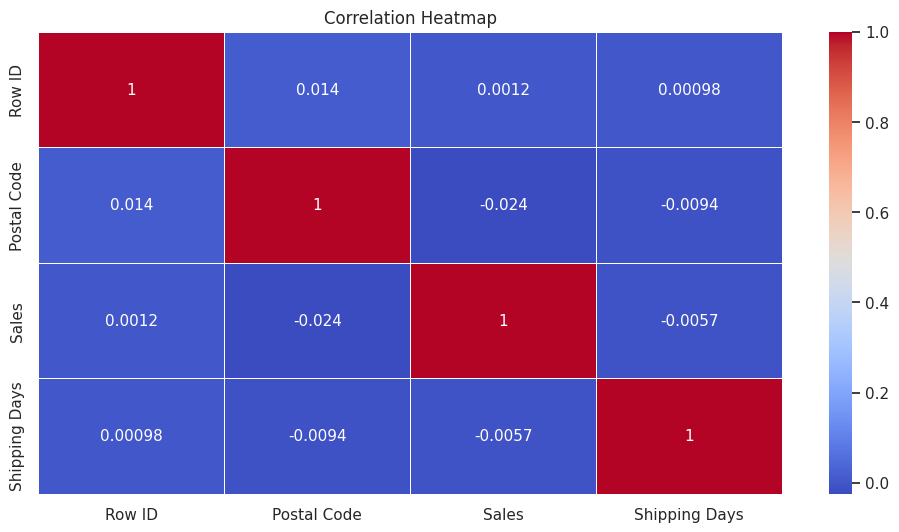

In [26]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure()
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

# **18. Shipping Days Analysis**

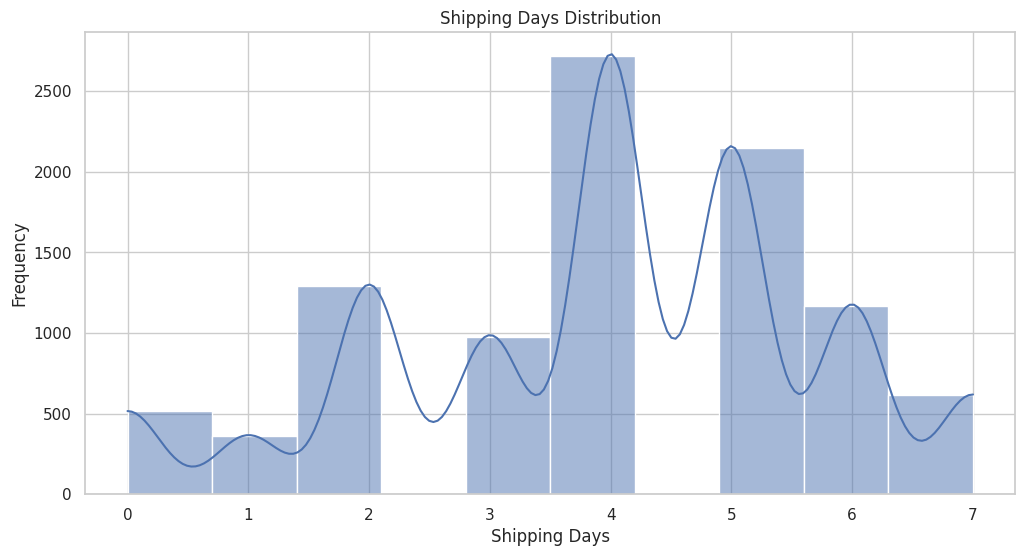


Average Shipping Days: 3.96


In [27]:
plt.figure()
sns.histplot(df["Shipping Days"], bins=10, kde=True)
plt.title("Shipping Days Distribution")
plt.xlabel("Shipping Days")
plt.ylabel("Frequency")
plt.show()

print("\nAverage Shipping Days:", round(df["Shipping Days"].mean(), 2))

# **RESULTS**

In [28]:
print("\nFINAL RESULTS")
print("-" * 60)

print("1. The dataset contains", df.shape[0], "records and", df.shape[1], "columns.")
print("2. Total Sales:", round(df["Sales"].sum(), 2))
print("3. Average Sales:", round(df["Sales"].mean(), 2))
print("4. Median Sales:", round(df["Sales"].median(), 2))
print("5. Highest Sales Transaction:", round(df["Sales"].max(), 2))
print("6. Sales distribution is right-skewed.")
print("7. Number of outliers detected using IQR:", outliers.shape[0])
print("8. Highest sales category:", category_sales.idxmax())
print("9. Highest sales region:", region_sales.idxmax())
print("10. Highest sales segment:", segment_sales.idxmax())

print("\nCONCLUSION")
print("""
The exploratory data analysis shows that the Superstore dataset has a highly right-skewed
sales distribution. Most orders are small-value transactions, while a smaller number of
large-value orders create significant outliers.

Technology is the strongest sales category, while the West region generates the highest
overall revenue. The Consumer segment contributes the largest share of sales.

The business should focus on high-performing categories, improve weaker regional sales,
and further investigate high-value outlier transactions because they may represent major
business opportunities rather than data errors.
""")


FINAL RESULTS
------------------------------------------------------------
1. The dataset contains 9800 records and 22 columns.
2. Total Sales: 2261536.78
3. Average Sales: 230.77
4. Median Sales: 54.49
5. Highest Sales Transaction: 22638.48
6. Sales distribution is right-skewed.
7. Number of outliers detected using IQR: 1145
8. Highest sales category: Technology
9. Highest sales region: West
10. Highest sales segment: Consumer

CONCLUSION

The exploratory data analysis shows that the Superstore dataset has a highly right-skewed
sales distribution. Most orders are small-value transactions, while a smaller number of
large-value orders create significant outliers.

Technology is the strongest sales category, while the West region generates the highest
overall revenue. The Consumer segment contributes the largest share of sales.

The business should focus on high-performing categories, improve weaker regional sales,
and further investigate high-value outlier transactions because they may

# **LAST STEP: Save Complete EDA Summary to CSV**

In [29]:
eda_summary = {
    "Metric": [
        "Dataset Name",
        "Total Rows",
        "Total Columns",
        "Duplicate Rows",
        "Missing Values",
        "Total Sales",
        "Average Sales",
        "Median Sales",
        "Minimum Sales",
        "Maximum Sales",
        "Standard Deviation",
        "Q1",
        "Q3",
        "IQR",
        "Lower Outlier Bound",
        "Upper Outlier Bound",
        "Total Outliers",
        "Highest Sales Category",
        "Highest Sales Region",
        "Highest Sales Segment",
        "Average Shipping Days",
        "Main Observation",
        "Final Conclusion"
    ],
    "Result": [
        "Superstore Sales Dataset",
        df.shape[0],
        df.shape[1],
        df.duplicated().sum(),
        df.isnull().sum().sum(),
        round(df["Sales"].sum(), 2),
        round(df["Sales"].mean(), 2),
        round(df["Sales"].median(), 2),
        round(df["Sales"].min(), 2),
        round(df["Sales"].max(), 2),
        round(df["Sales"].std(), 2),
        round(Q1, 2),
        round(Q3, 2),
        round(IQR, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        outliers.shape[0],
        category_sales.idxmax(),
        region_sales.idxmax(),
        segment_sales.idxmax(),
        round(df["Shipping Days"].mean(), 2),
        "Sales distribution is right-skewed with many high-value outliers.",
        "Technology and West Region are the strongest performers. High-value outliers should be investigated as business opportunities."
    ]
}

eda_summary_df = pd.DataFrame(eda_summary)

# Save file to system
eda_summary_df.to_csv("Complete_EDA_Project_2_Summary.csv", index=False)

print("EDA summary CSV file saved successfully!")
print("File Name: Complete_EDA_Project_2_Summary.csv")

EDA summary CSV file saved successfully!
File Name: Complete_EDA_Project_2_Summary.csv
